In [2]:
# Import libraries
library(readr)
library(dplyr)
library(ggplot2)
library(scales) # Date breaks in plots

# Yearly Water Billing

In [80]:
# Read CSV file
waterBill <- read_csv("../../data/Water_Billing.csv", show_col_types = FALSE)
# Summary of the data
glimpse(waterBill)

Rows: 3
Columns: 6
$ Year                   <dbl> 2012, 2013, 2014
$ `Flat Water`           <dbl> 512.88, 543.65, 573.55
$ `Sewer Pacel`          <dbl> 482.64, 511.60, 539.74
$ `Sewer Use`            <dbl> 0, 0, 0
$ `Garbage Disposal Fee` <dbl> 0, 75, 75
$ `Total Fees`           <dbl> 995.52, 1130.25, 1188.29


# Whole House Water Metering

In [81]:
# Read CSV file
WHW <- read_csv("../../data/Water_WHW.csv", show_col_types = FALSE) %>%
    # Columns transformation
    # Timestamp splitted into different columns (year, month, day, hour, minute) 
    # Goal: Will be usefull for aggregation and visualization later
    mutate(
        ts      =   as.POSIXct(unix_ts, origin = "1970-01-01 12:00:00"),
        date    =   as.Date(
                        format(as.POSIXct(unix_ts, origin = "1970-01-01 12:00:00"), format = "%Y-%m-%d"), 
                        format = "%Y-%m-%d"
                    ),
        year    =   format(as.POSIXct(unix_ts, origin = "1970-01-01 12:00:00"), format = "%Y"),
        month   =   format(as.POSIXct(unix_ts, origin = "1970-01-01 12:00:00"), format = "%m"),
        day     =   format(as.POSIXct(unix_ts, origin = "1970-01-01 12:00:00"), format = "%d"),
        hour    =   format(as.POSIXct(unix_ts, origin = "1970-01-01 12:00:00"), format = "%H"),
        minute  =   format(as.POSIXct(unix_ts, origin = "1970-01-01 12:00:00"), format = "%M"),
        second  =   format(as.POSIXct(unix_ts, origin = "1970-01-01 12:00:00"), format = "%S")
    ) %>%
    # Remove original timestamp column
    select(-unix_ts)

# Summary of the data
glimpse(WHW)

Rows: 1,051,200
Columns: 11
$ counter   <dbl> 45287.53, 45291.31, 45291.31, 45291.31, 45295.10, 45295.10, ~
$ avg_rate  <dbl> 0.000, 3.785, 0.000, 0.000, 3.785, 0.000, 0.000, 0.000, 0.00~
$ inst_rate <dbl> 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ~
$ ts        <dttm> 2012-04-01 15:00:00, 2012-04-01 15:01:00, 2012-04-01 15:02:~
$ date      <date> 2012-04-01, 2012-04-01, 2012-04-01, 2012-04-01, 2012-04-01,~
$ year      <chr> "2012", "2012", "2012", "2012", "2012", "2012", "2012", "201~
$ month     <chr> "04", "04", "04", "04", "04", "04", "04", "04", "04", "04", ~
$ day       <chr> "01", "01", "01", "01", "01", "01", "01", "01", "01", "01", ~
$ hour      <chr> "15", "15", "15", "15", "15", "15", "15", "15", "15", "15", ~
$ minute    <chr> "00", "01", "02", "03", "04", "05", "06", "07", "08", "09", ~
$ second    <chr> "00", "00", "00", "00", "00", "00", "00", "00", "00", "00", ~


In [16]:
# Find min and max dates per year for quick overview of the timeframe of the data
WHW %>%
    group_by(year) %>%
    summarise(
        minDate = min(date),
        maxDate = max(date)
    )

year,minDate,maxDate
<chr>,<date>,<date>
2012,2012-04-01,2012-12-31
2013,2013-01-01,2013-12-31
2014,2014-01-01,2014-04-01


In [82]:
# Find consumpton of water per hour
whwByDateHour <- WHW %>%
    group_by(year, month, date, hour) %>%
    summarise(
        waterCons = sum(avg_rate)
    )

`summarise()` has grouped output by 'year', 'month', 'date'. You can override
using the `.groups` argument.


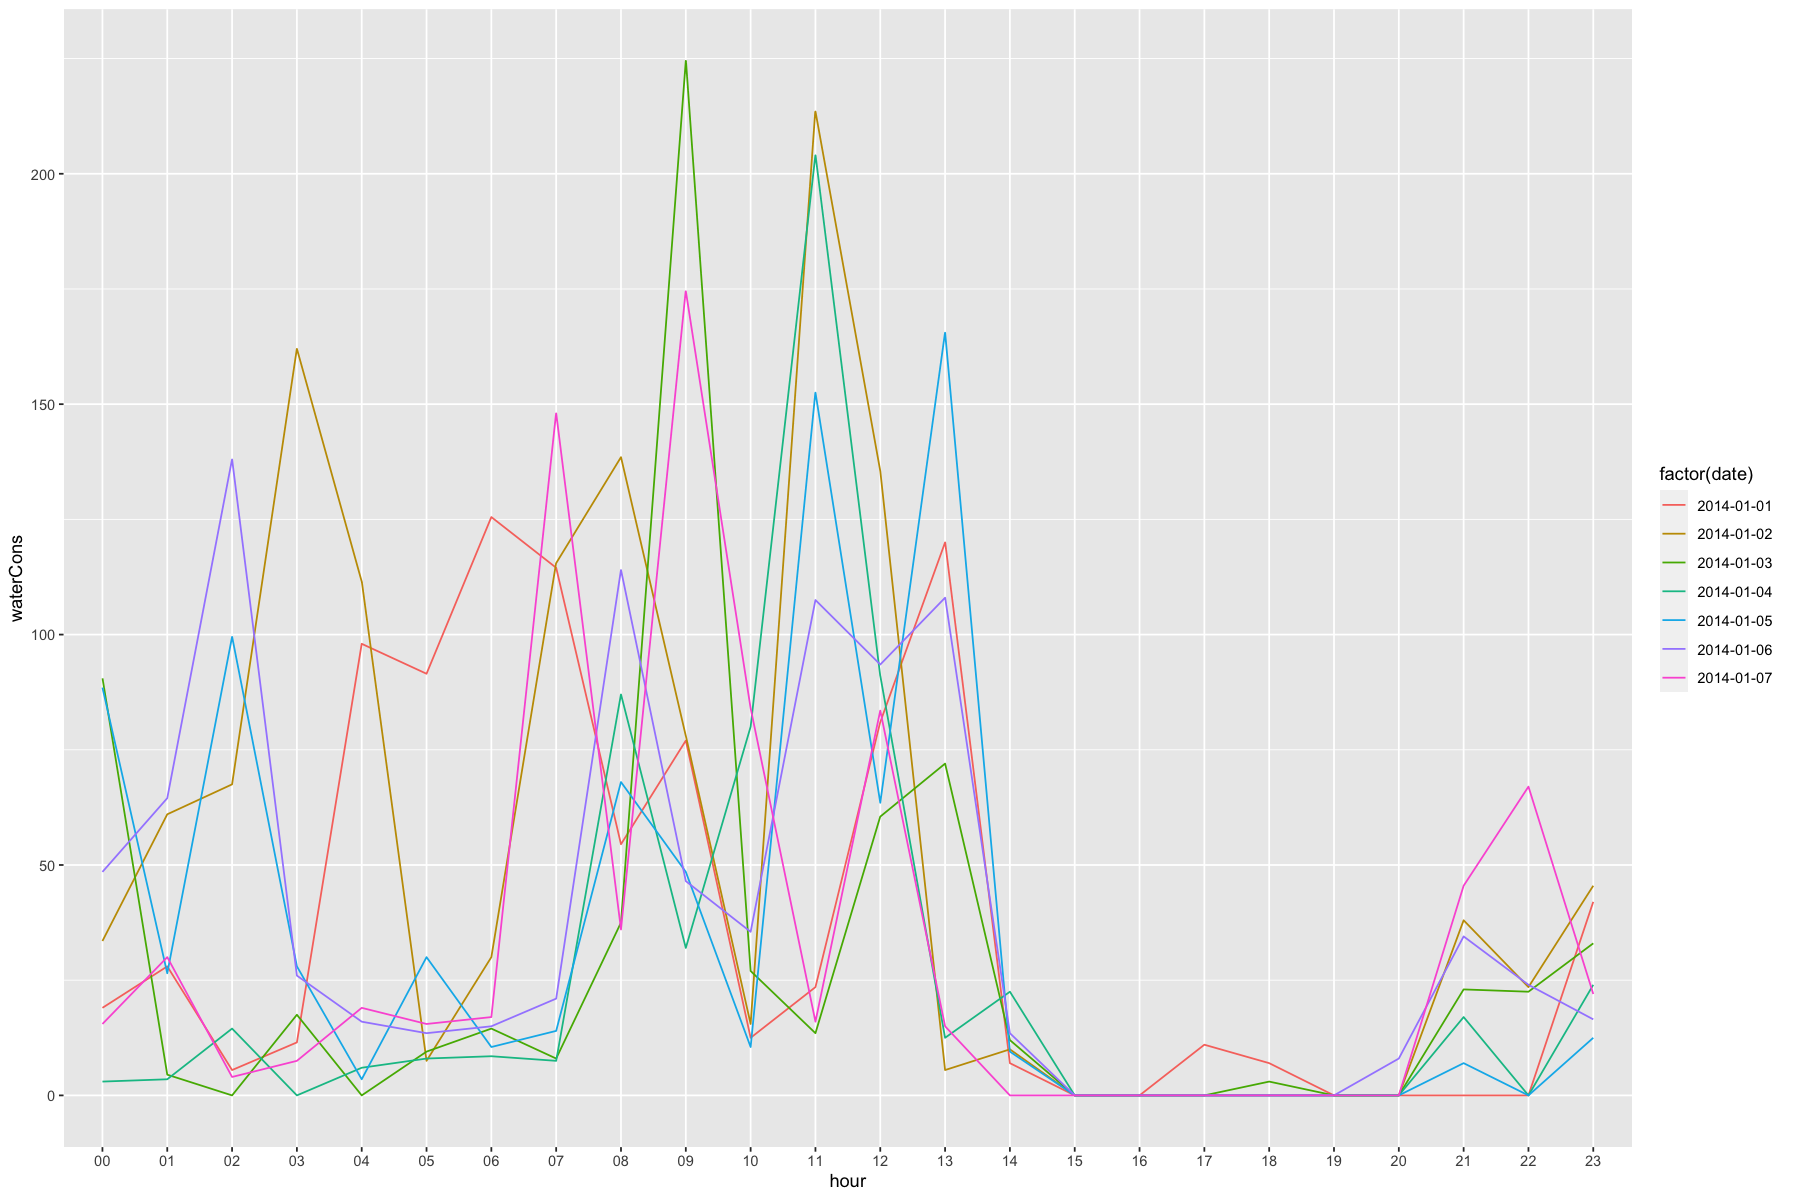

In [112]:
filteredDF <- whwByDateHour %>% 
    filter(date >= "2014-01-01", date <= "2014-01-07")

options(repr.plot.width = 15, repr.plot.height = 10)
ggplot(filteredDF, aes(x = hour, y = waterCons, color = factor(date), group = date)) +
    geom_line()

`summarise()` has grouped output by 'year'. You can override using the
`.groups` argument.


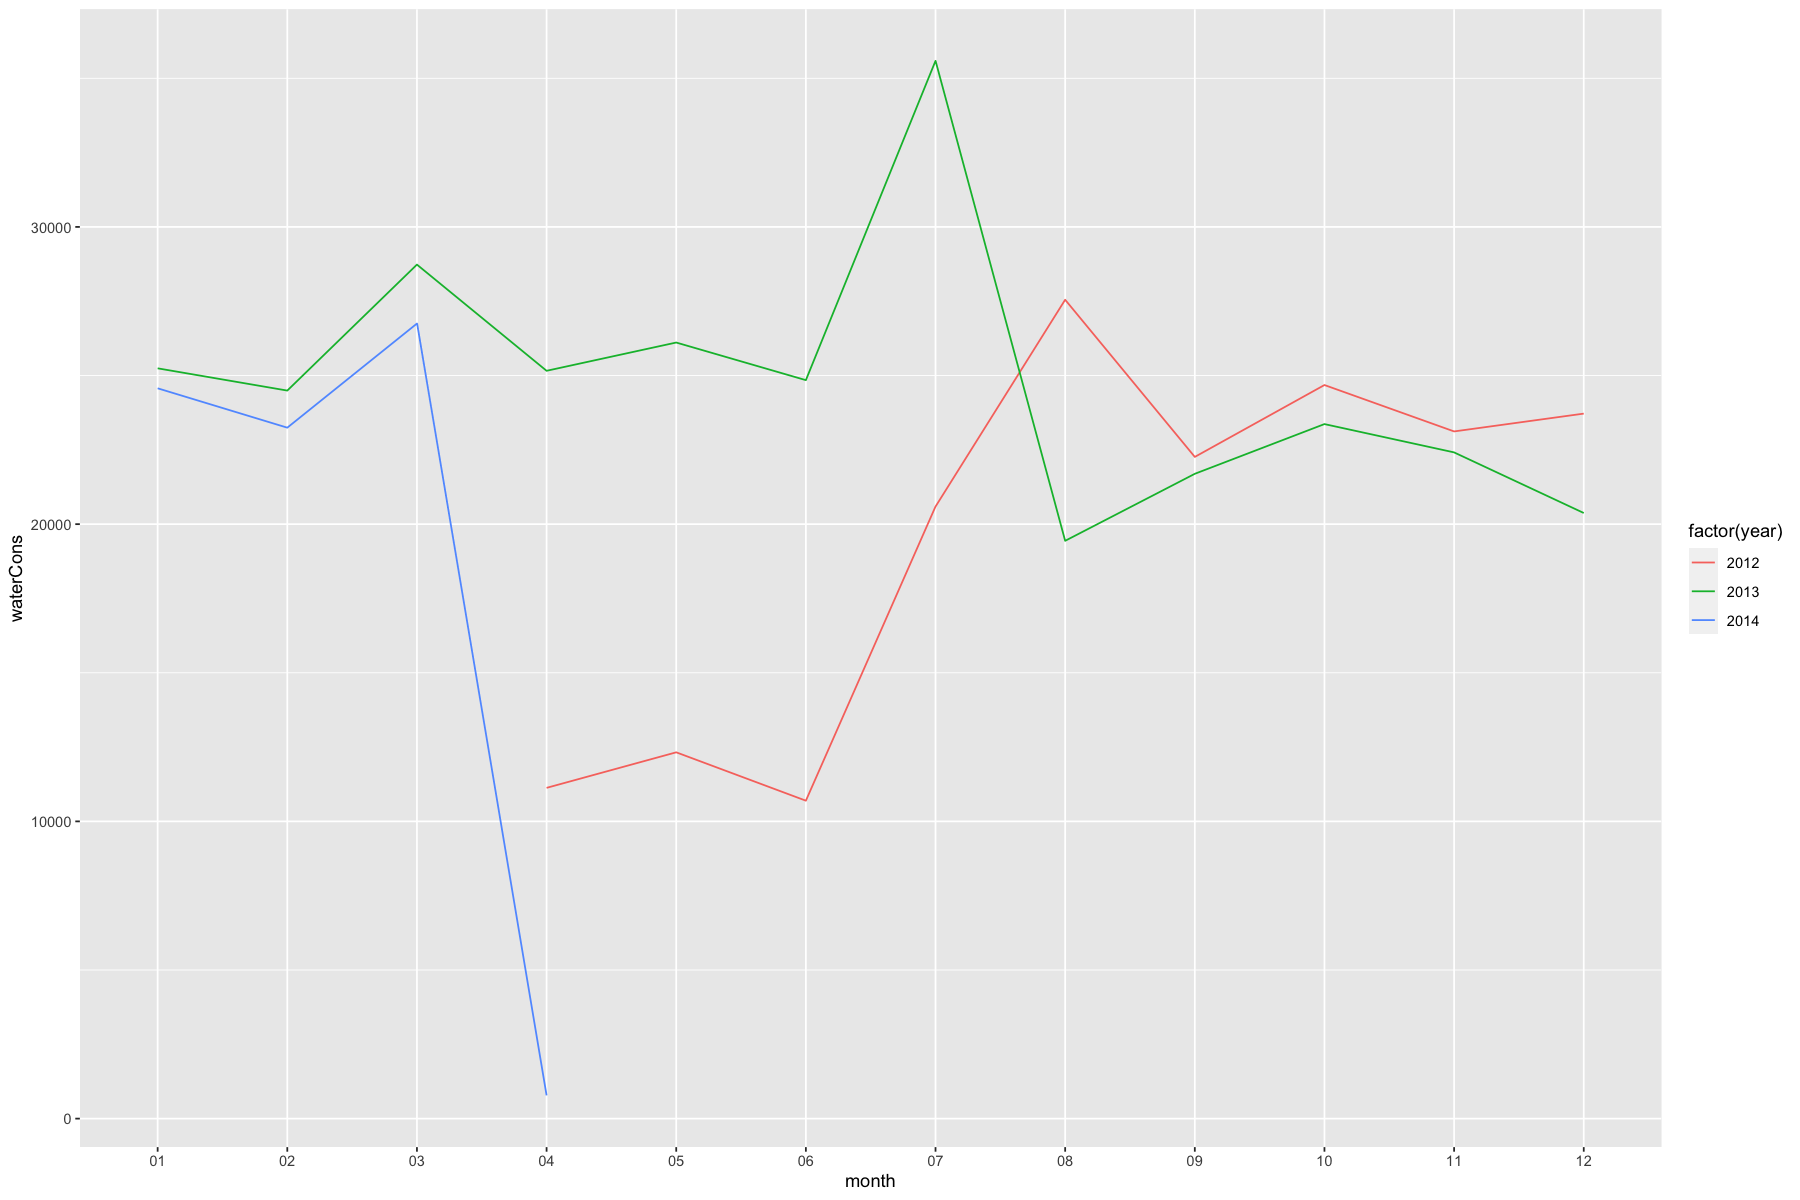

In [113]:
# Find consumpton of water per month
whwByMonth <- WHW %>%
    group_by(year, month) %>%
    summarise(
        waterCons = sum(avg_rate)
    )

options(repr.plot.width = 15, repr.plot.height = 10)
ggplot(whwByMonth, aes(x = month, y = waterCons, color = factor(year), group = factor(year))) +
    geom_line()

`summarise()` has grouped output by 'year', 'month'. You can override using the
`.groups` argument.


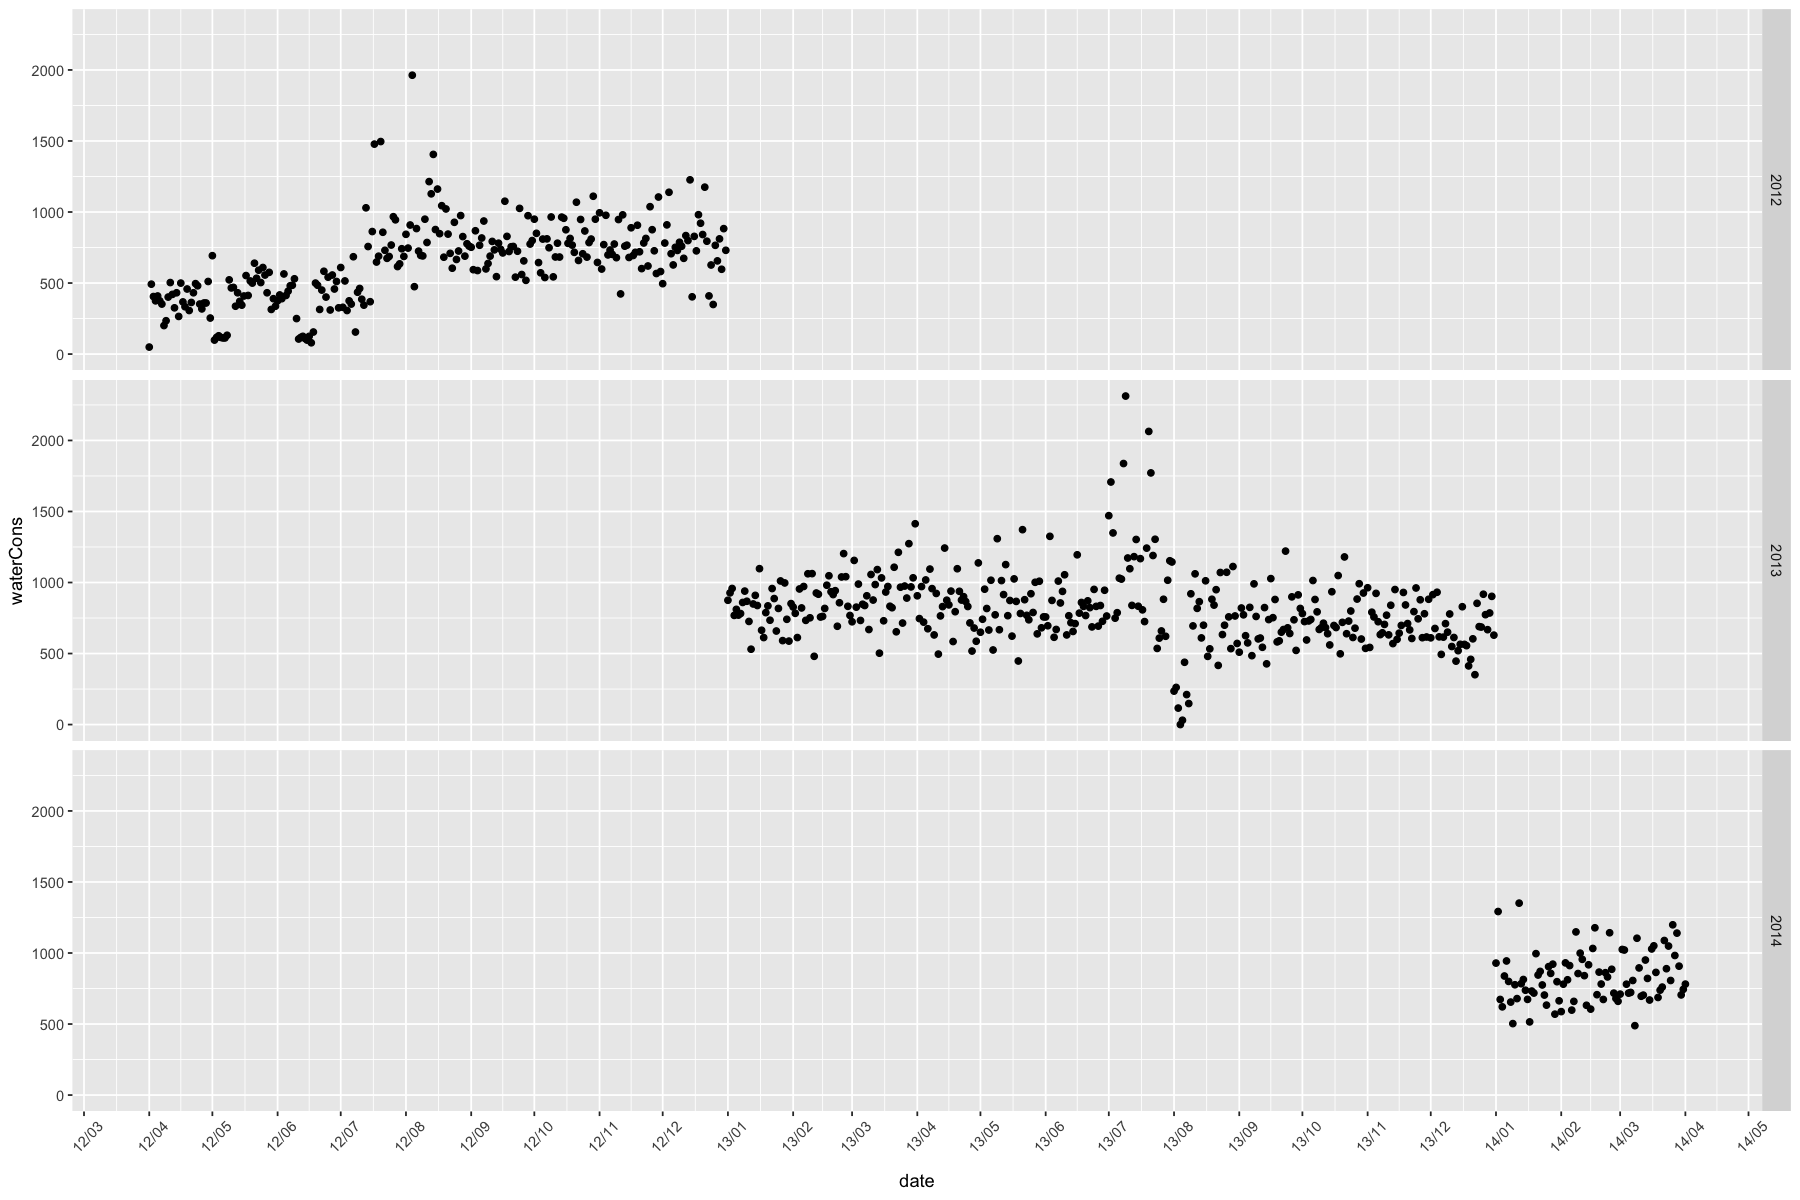

In [114]:
# Water consumption bt date
whwByDate <- WHW %>%
    group_by(year, month, date) %>%
    summarise(
        waterCons = sum(avg_rate)
    )

options(repr.plot.width = 15, repr.plot.height = 10)
ggplot(whwByDate, aes(x = date, y = waterCons)) +
    geom_point() +
    scale_x_date(
        labels = date_format("%y/%m"),
        breaks = date_breaks("months")
    ) +
    facet_grid(year ~ .) + 
    theme(
        axis.text.x = element_text(angle=45, margin=margin(10,0,0,0))
    )

`geom_smooth()` using formula = 'y ~ x'


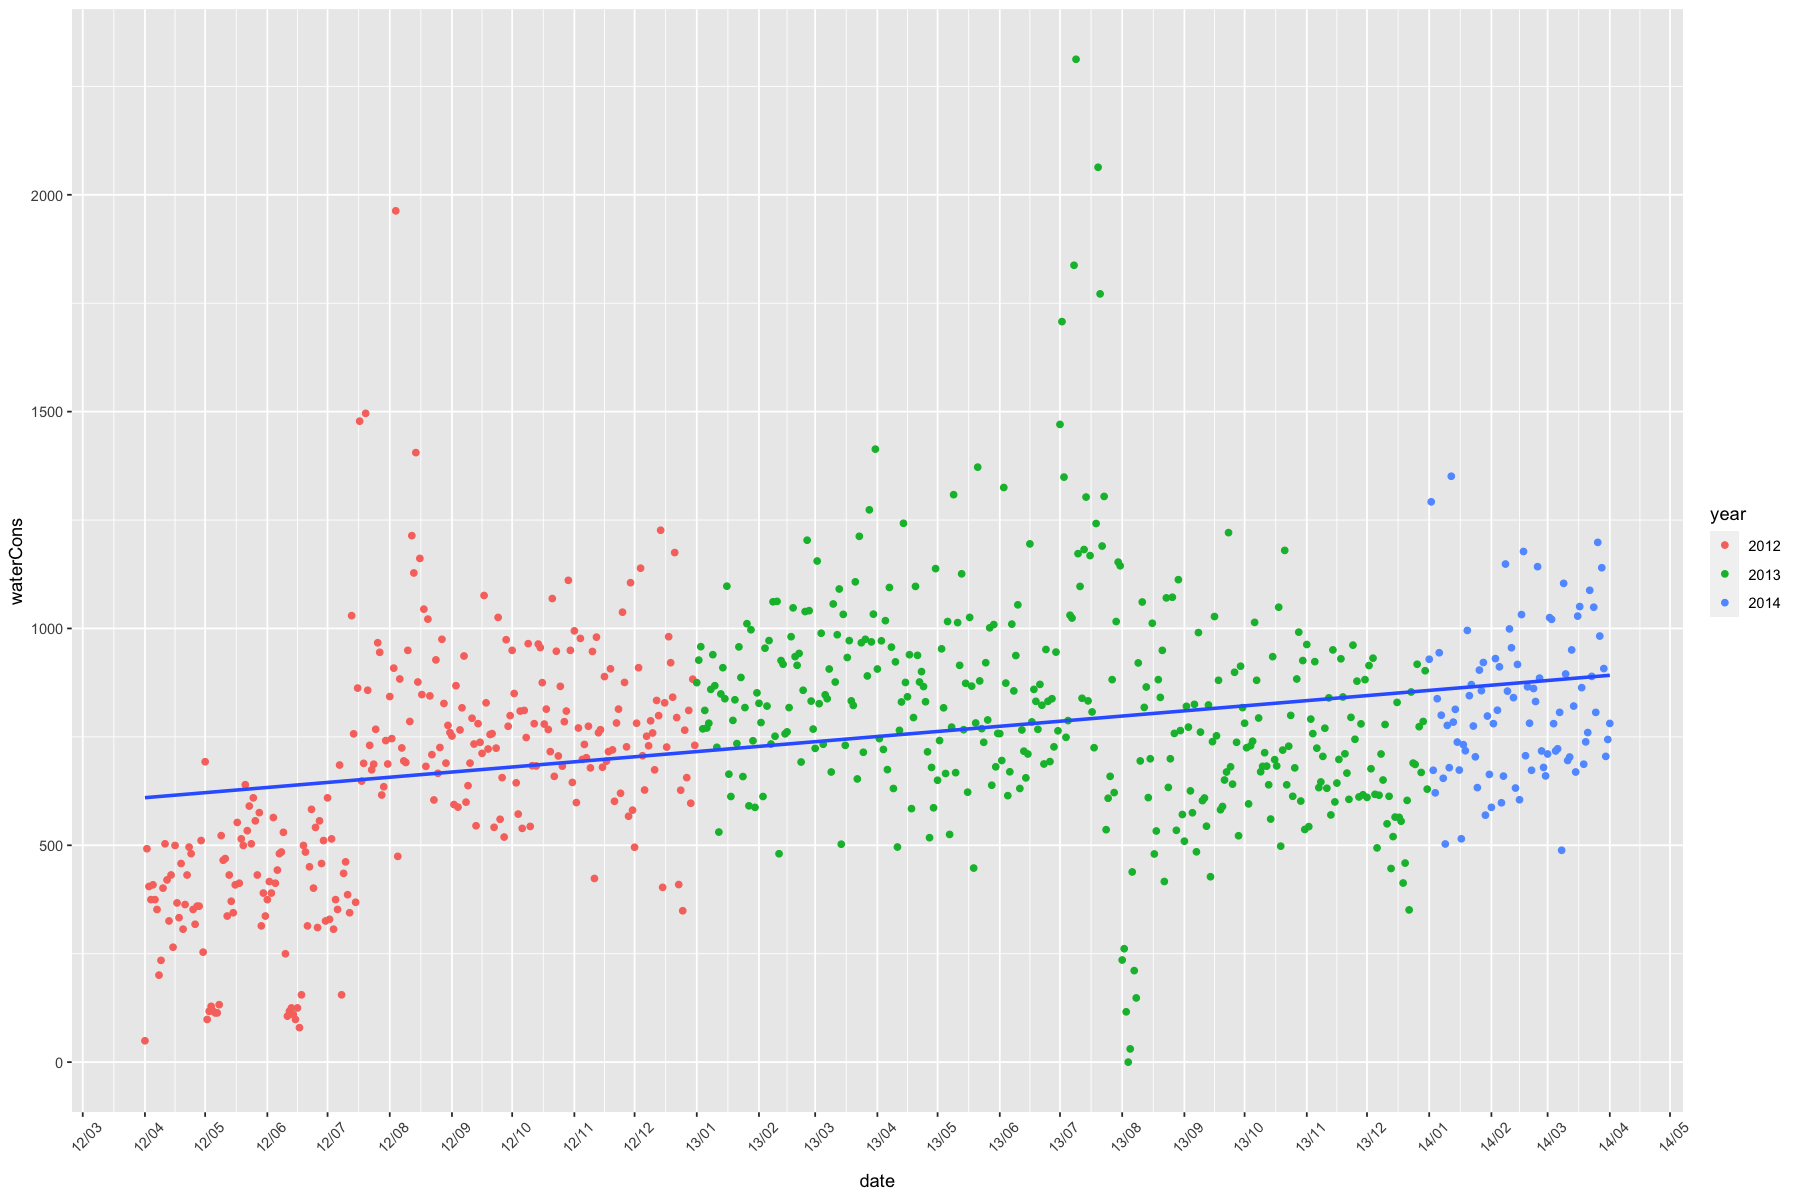

In [109]:
# Water consumption by date with a linear regression line
options(repr.plot.width = 15, repr.plot.height = 10)
ggplot(whwByDate, aes(x = date, y = waterCons)) +
    geom_point(aes(color = year)) +
    scale_x_date(
        labels = date_format("%y/%m"),
        breaks = date_breaks("months")
    ) +
    theme(
        axis.text.x = element_text(angle=45, margin=margin(10,0,0,0))
    ) +
    geom_smooth(method = "lm", se = FALSE)

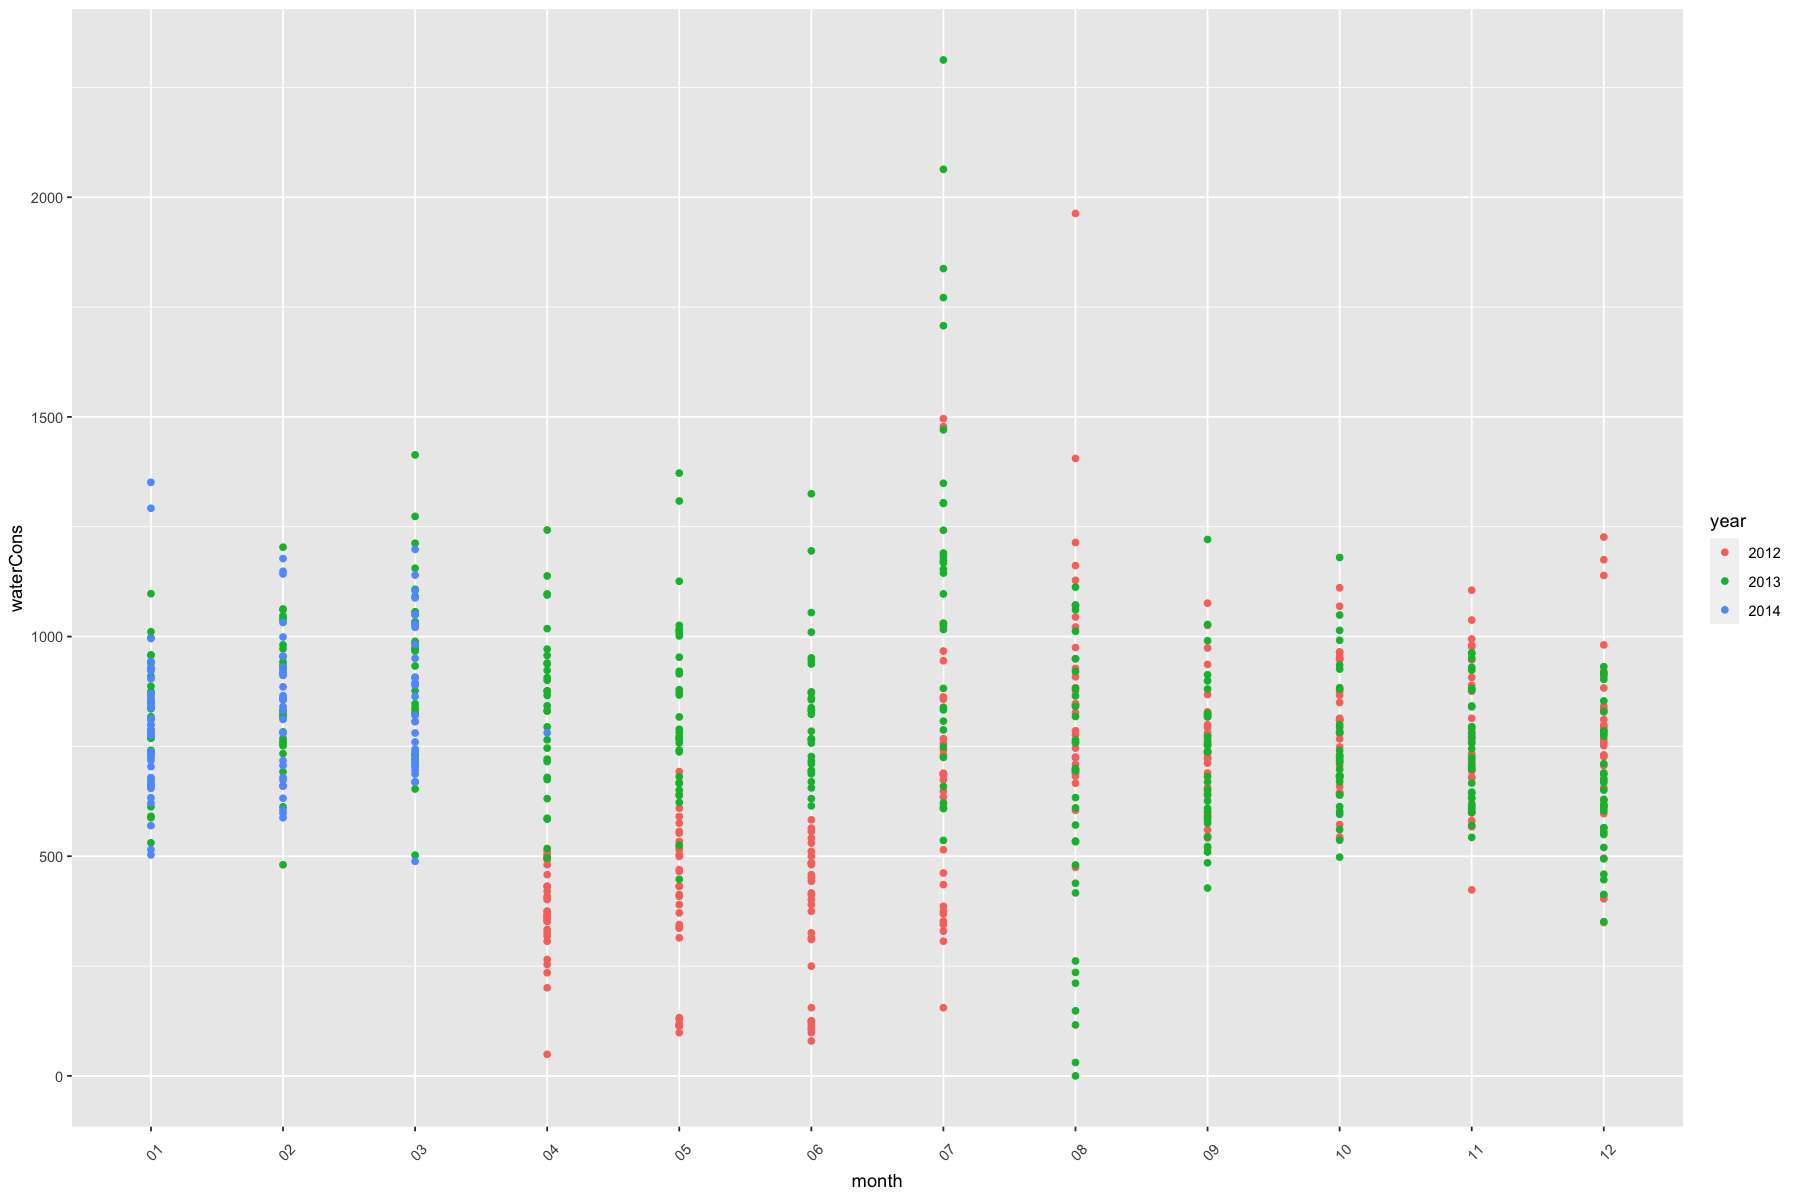

In [111]:
# Water cosumption by month
options(repr.plot.width = 15, repr.plot.height = 10)
ggplot(whwByDate, aes(x = month, y = waterCons)) +
    geom_point(aes(color = year)) +
    theme(
        axis.text.x = element_text(angle=45, margin=margin(10,0,0,0))
    )